# Soiling Analysis Options Guide

This notebook demonstrates the soiling analysis capabilities in RdTools v3, including:

1. **Stochastic Rate and Recovery (SRR)** - The primary soiling detection method
2. **Combined Degradation and Soiling (CODS)** - An alternative iterative decomposition approach

We'll explore the various parameters and options available for customizing the analysis to your specific dataset.

## Key Parameters in RdTools v3

| Parameter | Description | Default |
|-----------|-------------|----------|
| `detect_neg_shifts` | Detect negative shifts in rolling median and subdivide intervals | `False` |
| `piecewise_fit` | Test for piecewise linear fits within soiling intervals | `False` |
| `min_interval_days` | Minimum days for a valid interval | `7` |
| `max_neg_step` | Maximum negative step magnitude (only when `detect_neg_shifts=False`) | `0.05` |
| `neg_shift_factor` | Multiplier of `clean_threshold` for negative shift detection | `2.5` |
| `min_piecewise_days` | Minimum days to attempt piecewise fitting | `27` |
| `collapse_window_days` | Window for collapsing consecutive cleaning events | `5` |
| `forward_median_window` | Window for forward median validation | `10` |

## Cleaning Methods

| Method | Description | Use Case |
|--------|-------------|----------|
| `half_norm_clean` | Starting point from half-normal distribution | Default, most systems |
| `random_clean` | Random recovery 0-100% | Testing/comparison |
| `perfect_clean` | Each cleaning returns to 1 | Systems with complete cleaning |
| `inferred_clean` | Recovery inferred from data | Systems with partial cleaning |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import rdtools
from rdtools.soiling import SRRAnalysis, CODSAnalysis, soiling_srr
%matplotlib inline

# Update plot style
import matplotlib
matplotlib.rcParams.update({'font.size': 12,
                           'figure.figsize': [8, 4],
                           'lines.markeredgewidth': 0,
                           'lines.markersize': 2})

# Set random seed for reproducibility
np.random.seed(42)

c:\Users\mspringe\.conda\envs\rdtools_313-nb\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load Example Data

We'll use the PVDAQ dataset with a synthetic soiling signal for demonstration.

In [ ]:
# Import the example data
file_url = ('https://github.com/NatLabRockies/rdtools/releases/download/3.0.0/'
            'pvdaq_system_4_2010-2016_subset_soil_signal.csv')
cache_file = 'PVDAQ_system_4_2010-2016_subset_soilsignal.pickle'

try:
    df = pd.read_pickle(cache_file)
except FileNotFoundError:
    df = pd.read_csv(file_url, index_col=0, parse_dates=True)
    df.to_pickle(cache_file)

# Rename columns and set metadata
df = df.rename(columns={
    'ac_power': 'power_ac',
    'wind_speed': 'wind_speed',
    'ambient_temp': 'Tamb',
    'poa_irradiance': 'poa',
})

meta = {
    "latitude": 39.7406,
    "longitude": -105.1774,
    "timezone": 'Etc/GMT+7',
    "gamma_pdc": -0.005,
    "azimuth": 180,
    "tilt": 40,
    "power_dc_rated": 1000.0,
    "temp_model_params": 'open_rack_glass_polymer'
}

df.index = df.index.tz_localize(meta['timezone'])
df['power'] = df['power_ac'] * df['soiling']
freq = pd.infer_freq(df.index[:10])

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

Data shape: (1558875, 10)
Date range: 2010-02-25 14:16:00-07:00 to 2016-12-13 09:57:00-07:00


## Prepare Aggregated Daily Data

Soiling analysis works with daily aggregated normalized performance data. We'll use the `TrendAnalysis` class to prepare this data.

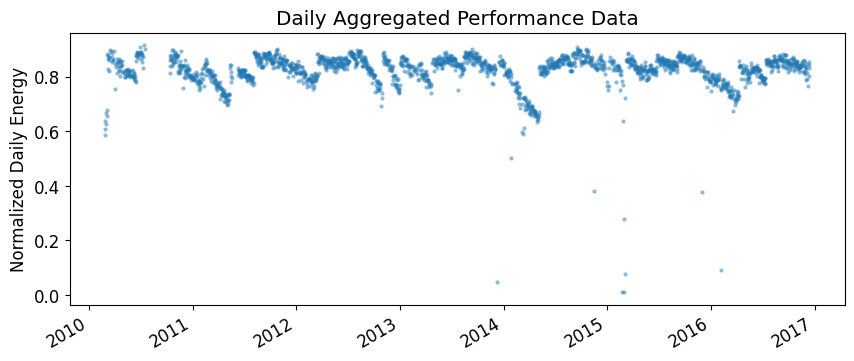

In [3]:
# Create TrendAnalysis object and run sensor analysis
ta = rdtools.TrendAnalysis(
    df['power'], df['poa'],
    temperature_ambient=df['Tamb'],
    gamma_pdc=meta['gamma_pdc'],
    interp_freq=freq,
    windspeed=df['wind_speed'],
    power_dc_rated=meta['power_dc_rated'],
    temperature_model=meta['temp_model_params']
)

# Run basic analysis to get aggregated data
ta.sensor_analysis(analyses=['yoy_degradation'])

# Extract daily aggregated performance and insolation
energy_normalized_daily = ta.sensor_aggregated_performance
insolation_daily = ta.sensor_aggregated_insolation

# Plot the daily data
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(energy_normalized_daily.index, energy_normalized_daily, 'o', alpha=0.5, markersize=3)
ax.set_ylabel('Normalized Daily Energy')
ax.set_title('Daily Aggregated Performance Data')
fig.autofmt_xdate()
plt.show()

---
# Part 1: Stochastic Rate and Recovery (SRR) Analysis

The SRR method identifies soiling intervals and estimates soiling rates using Monte Carlo simulations.

## 1.1 Basic SRR Analysis (Default Settings)

Start with the default parameters to establish a baseline.

In [4]:
# Basic SRR analysis with defaults
sr_basic, sr_ci_basic, info_basic = soiling_srr(
    energy_normalized_daily,
    insolation_daily,
    reps=500  # Reduced for speed; use 1000+ for production
)

print(f"Basic SRR Results:")
print(f"  Soiling Ratio (P50): {sr_basic:.4f}")
print(f"  Confidence Interval: ({sr_ci_basic[0]:.4f}, {sr_ci_basic[1]:.4f})")

Basic SRR Results:
  Soiling Ratio (P50): 0.9513
  Confidence Interval: (0.9468, 0.9545)


## 1.2 Comparing Cleaning Methods

Different cleaning methods make different assumptions about how much soiling is removed during cleaning events.

In [5]:
# Compare different cleaning methods
methods = ['half_norm_clean', 'random_clean', 'perfect_clean']
results = {}

for method in methods:
    sr, sr_ci, info = soiling_srr(
        energy_normalized_daily,
        insolation_daily,
        reps=500,
        method=method
    )
    results[method] = {'sr': sr, 'ci': sr_ci}
    print(f"{method:20s}: SR = {sr:.4f} ({sr_ci[0]:.4f}, {sr_ci[1]:.4f})")

half_norm_clean     : SR = 0.9512 (0.9473, 0.9548)
random_clean        : SR = 0.9042 (0.8902, 0.9169)
perfect_clean       : SR = 0.9718 (0.9711, 0.9726)


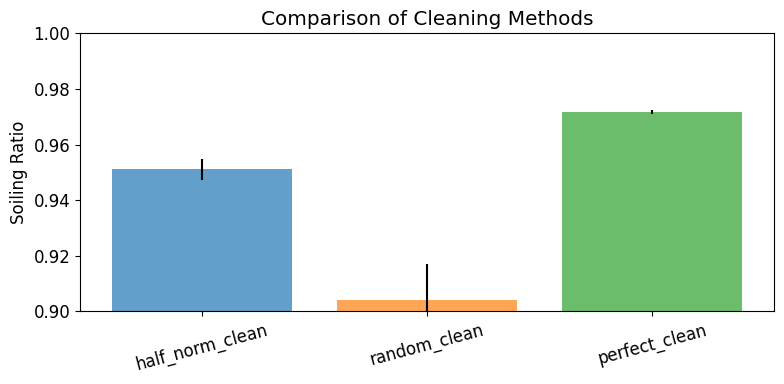

In [6]:
# Visualize the comparison
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(methods))
srs = [results[m]['sr'] for m in methods]
lows = [results[m]['ci'][0] for m in methods]
highs = [results[m]['ci'][1] for m in methods]
errors = [[sr - low for sr, low in zip(srs, lows)],
          [high - sr for sr, high in zip(srs, highs)]]

ax.bar(x, srs, yerr=errors, capsize=5, alpha=0.7, color=['C0', 'C1', 'C2'])
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel('Soiling Ratio')
ax.set_title('Comparison of Cleaning Methods')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

## 1.3 Advanced SRR with Negative Shift Detection

The `detect_neg_shifts=True` option enables detection of negative shifts in the rolling median, which subdivides intervals at these points. This is useful for datasets with:
- Partial cleaning events
- Equipment changes
- Non-soiling performance changes within intervals

When `detect_neg_shifts=True`, use `method='perfect_clean'` or `method='inferred_clean'` for enhanced logic.

In [ ]:
# SRR with negative shift detection
# neg_shift_factor controls sensitivity: shifts > neg_shift_factor * clean_threshold
# trigger interval subdivision (default: 2.5)
sr_neg_shift, sr_ci_neg_shift, info_neg_shift = soiling_srr(
    energy_normalized_daily,
    insolation_daily,
    reps=500,
    detect_neg_shifts=True,
    method='perfect_clean',
    neg_shift_factor=2.5  # Default value; decrease for more sensitivity
)

print(f"SRR with Negative Shift Detection:")
print(f"  Soiling Ratio (P50): {sr_neg_shift:.4f}")
print(f"  Confidence Interval: ({sr_ci_neg_shift[0]:.4f}, {sr_ci_neg_shift[1]:.4f})")

SRR with Negative Shift Detection:
  Soiling Ratio (P50): 0.9588
  Confidence Interval: (0.9570, 0.9610)


## 1.4 Advanced SRR with Piecewise Fitting

The `piecewise_fit=True` option tests whether each soiling interval is better described by two linear segments (a change point) rather than one. This is useful when:
- Soiling rate changes mid-interval (e.g., seasonal variation)
- There are undetected partial cleaning events

In [8]:
# SRR with piecewise fitting
sr_piecewise, sr_ci_piecewise, info_piecewise = soiling_srr(
    energy_normalized_daily,
    insolation_daily,
    reps=500,
    piecewise_fit=True,
    min_piecewise_days=27  # Minimum interval length to attempt piecewise fit
)

print(f"SRR with Piecewise Fitting:")
print(f"  Soiling Ratio (P50): {sr_piecewise:.4f}")
print(f"  Confidence Interval: ({sr_ci_piecewise[0]:.4f}, {sr_ci_piecewise[1]:.4f})")

C:\Users\mspringe\OneDrive - NREL\msp\pvfleets\repos\public\rdtools\rdtools\soiling.py:1207: UserWarning: 20% or more of the daily data is assigned to invalid soiling intervals. This can be problematic with the "half_norm_clean" and "random_clean" cleaning assumptions. Consider more permissive validity criteria such as increasing "max_relative_slope_error" and/or "max_neg_step" and/or decreasing "min_interval_days". Alternatively, consider using method="perfect_clean". For more info see https://github.com/NREL/rdtools/issues/272
  sr, sr_ci, soiling_info = srr.run(


SRR with Piecewise Fitting:
  Soiling Ratio (P50): 0.9550
  Confidence Interval: (0.9505, 0.9583)


## 1.5 Combined Advanced Analysis

For complex datasets, you can combine both `detect_neg_shifts=True` and `piecewise_fit=True` along with `inferred_clean` for maximum flexibility.

In [9]:
# Full advanced SRR analysis
sr_advanced, sr_ci_advanced, info_advanced = soiling_srr(
    energy_normalized_daily,
    insolation_daily,
    reps=500,
    method='inferred_clean',
    detect_neg_shifts=True,
    piecewise_fit=True,
    neg_shift_factor=2.5,       # Multiplier for negative shift threshold
    min_piecewise_days=27,      # Min days for piecewise attempt
    collapse_window_days=5,     # Window for collapsing cleaning events
    forward_median_window=10    # Window for forward median validation
)

print(f"Advanced SRR (detect_neg_shifts + piecewise_fit + inferred_clean):")
print(f"  Soiling Ratio (P50): {sr_advanced:.4f}")
print(f"  Confidence Interval: ({sr_ci_advanced[0]:.4f}, {sr_ci_advanced[1]:.4f})")

Advanced SRR (detect_neg_shifts + piecewise_fit + inferred_clean):
  Soiling Ratio (P50): 0.9286
  Confidence Interval: (0.9265, 0.9307)


## 1.6 Using the SRRAnalysis Class Directly

For more control and access to intermediate results, use the `SRRAnalysis` class directly.

In [10]:
# Create SRRAnalysis instance
srr = SRRAnalysis(energy_normalized_daily, insolation_daily)

# Run the analysis with custom parameters
sr, sr_ci, info = srr.run(
    reps=500,
    method='perfect_clean',
    detect_neg_shifts=True,
    piecewise_fit=True,
    min_interval_days=7,
    max_relative_slope_error=500.0
)

print(f"SRRAnalysis Class Results:")
print(f"  Soiling Ratio: {sr:.4f}")
print(f"  Number of valid intervals: {srr.result_df['valid'].sum()}")

SRRAnalysis Class Results:
  Soiling Ratio: 0.9634
  Number of valid intervals: 66


In [11]:
# Access the soiling interval summary
interval_summary = info['soiling_interval_summary']
valid_intervals = interval_summary[interval_summary['valid']]
print(f"Valid soiling intervals: {len(valid_intervals)}")
valid_intervals[['start', 'end', 'soiling_rate', 'soiling_rate_low', 'soiling_rate_high', 'length']].head(10)

Valid soiling intervals: 66


,start,end,soiling_rate,soiling_rate_low,soiling_rate_high,length
1,2010-03-06 00:00:00-07:00,2010-03-18 00:00:00-07:00,0.000000,0.000000,0.000000,12
2,2010-03-19 00:00:00-07:00,2010-04-08 00:00:00-07:00,-0.003089,-0.006783,-0.000300,20
3,2010-04-09 00:00:00-07:00,2010-04-21 00:00:00-07:00,-0.002861,-0.007496,0.000000,12
4,2010-04-22 00:00:00-07:00,2010-06-13 00:00:00-07:00,-0.000890,-0.001203,-0.000520,52
5,2010-06-14 00:00:00-07:00,2010-06-28 00:00:00-07:00,0.000000,0.000000,0.000000,14
6,2010-06-29 00:00:00-07:00,2010-07-13 00:00:00-07:00,-0.004741,-0.009892,-0.001985,14
9,2010-10-11 00:00:00-07:00,2010-10-23 00:00:00-07:00,0.000000,0.000000,0.000000,12
10,2010-10-24 00:00:00-07:00,2011-01-29 00:00:00-07:00,-0.001246,-0.001402,-0.001072,97
12,2011-02-11 00:00:00-07:00,2011-03-14 00:00:00-07:00,-0.001913,-0.002793,-0.001307,31
13,2011-03-15 00:00:00-07:00,2011-04-30 00:00:00-07:00,-0.001913,-0.002287,-0.001578,46


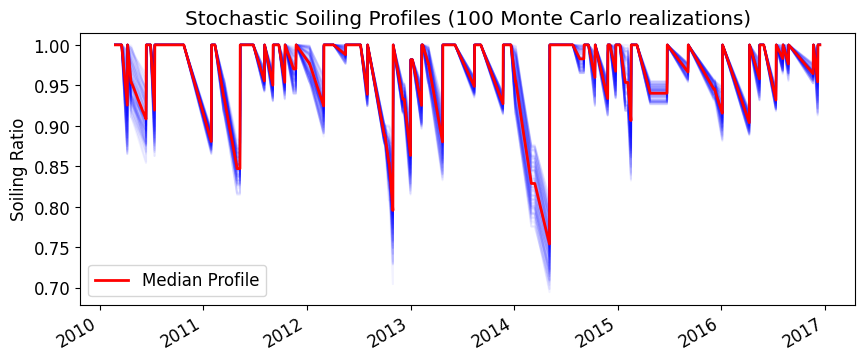

In [12]:
# Plot the stochastic soiling profiles
fig, ax = plt.subplots(figsize=(10, 4))

# Plot a subset of the Monte Carlo profiles
profiles = info['stochastic_soiling_profiles']
for i, profile in enumerate(profiles[:100]):
    ax.plot(profile.index, profile.values, alpha=0.05, color='blue')

# Plot the median profile
median_profile = pd.concat(profiles, axis=1).median(axis=1)
ax.plot(median_profile.index, median_profile.values, color='red', linewidth=2, label='Median Profile')

ax.set_ylabel('Soiling Ratio')
ax.set_title('Stochastic Soiling Profiles (100 Monte Carlo realizations)')
ax.legend()
fig.autofmt_xdate()
plt.show()

## 1.7 Summary: Comparing All SRR Configurations

In [13]:
# Summary comparison
summary_data = {
    'Configuration': [
        'Basic (defaults)',
        'detect_neg_shifts=True',
        'piecewise_fit=True',
        'Advanced (both + inferred_clean)'
    ],
    'Soiling Ratio': [sr_basic, sr_neg_shift, sr_piecewise, sr_advanced],
    'CI Low': [sr_ci_basic[0], sr_ci_neg_shift[0], sr_ci_piecewise[0], sr_ci_advanced[0]],
    'CI High': [sr_ci_basic[1], sr_ci_neg_shift[1], sr_ci_piecewise[1], sr_ci_advanced[1]]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Soiling Loss (%)'] = (1 - summary_df['Soiling Ratio']) * 100
print(summary_df.to_string(index=False))

                   Configuration  Soiling Ratio   CI Low  CI High  Soiling Loss (%)
                Basic (defaults)       0.951282 0.946841 0.954526          4.871779
          detect_neg_shifts=True       0.958811 0.956984 0.960953          4.118865
              piecewise_fit=True       0.955015 0.950515 0.958287          4.498539
Advanced (both + inferred_clean)       0.928642 0.926526 0.930723          7.135753


---
# Part 2: Combined Degradation and Soiling (CODS) Analysis

CODS is an alternative approach that simultaneously estimates degradation, soiling, and seasonal components using iterative signal decomposition.

## 2.1 Basic CODS Analysis

In [14]:
# Create CODS instance
cods = CODSAnalysis(energy_normalized_daily)

# Run bootstrap analysis (use reps=512 for production; 16 is minimum)
results_df, degradation, soiling_loss = cods.run_bootstrap(reps=16, bootstrap_seed=42)

print(f"CODS Results:")
print(f"  Degradation Rate: {cods.degradation[0]:.3f}% ({cods.degradation[1]:.3f}, {cods.degradation[2]:.3f})")
print(f"  Soiling Loss: {cods.soiling_loss[0]:.3f}% ({cods.soiling_loss[1]:.3f}, {cods.soiling_loss[2]:.3f})")

CODS Results:
  Degradation Rate: -0.187% (-0.304, -0.086)
  Soiling Loss: 5.915% (4.707, 6.788)


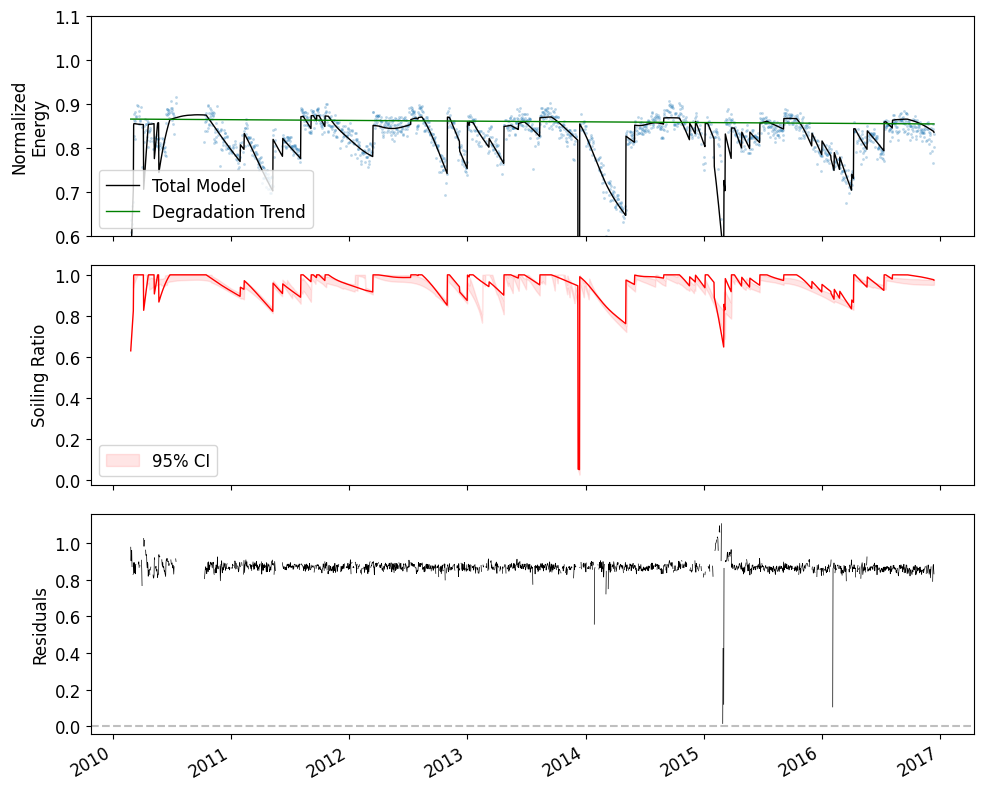

In [ ]:
# Plot CODS results
result_df = cods.result_df

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Panel 1: Performance data with model fit
axes[0].plot(energy_normalized_daily.index, energy_normalized_daily, 'o', alpha=0.3, markersize=2)
axes[0].plot(result_df.index, result_df.total_model, color='k', linewidth=1, label='Total Model')
axes[0].plot(result_df.index, result_df.degradation_trend * cods.residual_shift,
             color='g', linewidth=1, label='Degradation Trend')
axes[0].set_ylabel('Normalized\nEnergy')
axes[0].set_ylim(0.6, 1.1)
axes[0].legend(loc='lower left')

# Panel 2: Soiling ratio
axes[1].plot(result_df.index, result_df.soiling_ratio, color='r', linewidth=1)
axes[1].fill_between(result_df.index, result_df.SR_low, result_df.SR_high,
                     color='r', alpha=0.1, label='95% CI')
axes[1].set_ylabel('Soiling Ratio')
axes[1].legend()

# Panel 3: Residuals
axes[2].plot(result_df.index, result_df.residuals, color='k', linewidth=0.5)
axes[2].set_ylabel('Residuals')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 2.2 CODS with Custom Component Order

CODS allows you to specify the order in which components are extracted using the `order` parameter.

In [16]:
# CODS with different component orders
# Default order: ['SR', 'SC', 'Rd'] (Soiling, Seasonal, Degradation)
# Alternative: ['SR', 'Rd', 'SC'] or ['Rd', 'SR', 'SC']

cods_alt = CODSAnalysis(energy_normalized_daily)
df_out, results_dict = cods_alt.iterative_signal_decomposition(
    order=['SR', 'Rd', 'SC'],  # Extract degradation before seasonal
    max_iterations=5
)

print(f"CODS (SR→Rd→SC order):")
print(f"  Degradation: {results_dict['degradation']:.3f}%")
print(f"  Soiling Loss: {results_dict['soiling_loss']:.3f}%")

CODS (SR→Rd→SC order):
  Degradation: -0.301%
  Soiling Loss: 4.668%


## 2.3 Accessing CODS Cleaning Events

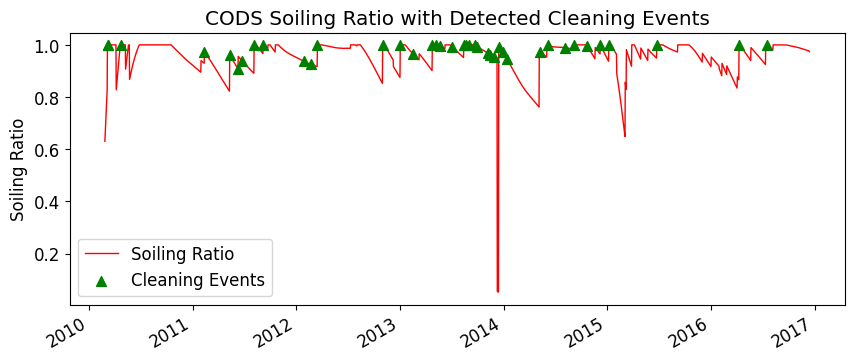

In [ ]:
# Visualize detected cleaning events
result_df = cods.result_df

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result_df.index, result_df.soiling_ratio, color='r', linewidth=1, label='Soiling Ratio')

# Mark cleaning events (where probability > 0.5)
if 'cleaning_events' in result_df.columns:
    cleaning_mask = result_df.cleaning_events > 0.5
    ax.scatter(result_df.index[cleaning_mask],
               result_df.soiling_ratio[cleaning_mask],
               color='green', s=50, marker='^', label='Cleaning Events', zorder=5)

ax.set_ylabel('Soiling Ratio')
ax.set_title('CODS Soiling Ratio with Detected Cleaning Events')
ax.legend()
fig.autofmt_xdate()
plt.show()

---
# Part 3: Choosing the Right Configuration

## Decision Guide

| Scenario | Recommended Configuration |
|----------|---------------------------|
| **Standard analysis** | `soiling_srr()` with defaults |
| **Systems with complete cleaning** | `method='perfect_clean'` |
| **Systems with partial cleaning** | `method='inferred_clean'` + `detect_neg_shifts=True` |
| **Variable soiling rates** | `piecewise_fit=True` |
| **Complex soiling patterns** | `detect_neg_shifts=True` + `piecewise_fit=True` |
| **Joint degradation + soiling** | `CODSAnalysis` |
| **Noisy data** | Increase `min_interval_days`, decrease `max_relative_slope_error` |

## Parameter Tuning Tips

### `min_interval_days`
- **Increase** if you're getting too many short, noisy intervals
- **Decrease** if you're missing short but valid soiling periods

### `max_neg_step` (only when `detect_neg_shifts=False`)
- **Increase** to be more permissive of noise
- **Decrease** to be stricter about interval validity

### `neg_shift_factor`
- **Increase** to require larger shifts before subdividing
- **Decrease** to be more sensitive to smaller shifts

### `clean_threshold`
- Use `'infer'` (default) to automatically determine from data
- Specify a numeric value if you have domain knowledge about typical cleaning magnitude

In [18]:
# Example: Tuning for noisy data
sr_tuned, sr_ci_tuned, info_tuned = soiling_srr(
    energy_normalized_daily,
    insolation_daily,
    reps=500,
    min_interval_days=14,           # Require longer intervals
    max_relative_slope_error=300.0, # Stricter slope error threshold
    max_neg_step=0.08               # More permissive of negative steps
)

print(f"Tuned for noisy data:")
print(f"  Soiling Ratio: {sr_tuned:.4f} ({sr_ci_tuned[0]:.4f}, {sr_ci_tuned[1]:.4f})")

C:\Users\mspringe\OneDrive - NREL\msp\pvfleets\repos\public\rdtools\rdtools\soiling.py:1207: UserWarning: 20% or more of the daily data is assigned to invalid soiling intervals. This can be problematic with the "half_norm_clean" and "random_clean" cleaning assumptions. Consider more permissive validity criteria such as increasing "max_relative_slope_error" and/or "max_neg_step" and/or decreasing "min_interval_days". Alternatively, consider using method="perfect_clean". For more info see https://github.com/NREL/rdtools/issues/272
  sr, sr_ci, soiling_info = srr.run(


Tuned for noisy data:
  Soiling Ratio: 0.9530 (0.9490, 0.9564)


---
## Summary

This notebook demonstrated the soiling analysis capabilities in RdTools v3:

1. **SRR Analysis** with various cleaning methods and advanced options
2. **CODS Analysis** for joint degradation and soiling estimation
3. **Parameter tuning** guidelines for different scenarios

For more details, see:
- [RdTools Documentation](https://rdtools.readthedocs.io/)
- The source code in `rdtools/soiling.py`